# Phase 8 — Anomaly Detection

Three methods — IQR, Z-score, Isolation Forest — applied across 5 domains: daily sales, inventory changes, shipment delays, transport costs, and supplier lead times (`src/anomaly_detection/{detectors,data,pipeline}.py`). Every flagged point is emitted in one schema: `anomaly_id, date, entity, metric, method, expected_value, actual_value, anomaly_score, severity`.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.anomaly_detection.data import load_daily_sales
from src.anomaly_detection.detectors import METHODS
from src.anomaly_detection.pipeline import detect_all, detect_domain

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


## 1. Run all 3 methods across all 5 domains

`inventory_change` (per warehouse) and `supplier_lead_time` (per supplier) are detected *within each entity's own history* — a shipment unusual for one supplier isn't necessarily unusual network-wide. The other three domains are judged against one global population (`src/anomaly_detection/data.py`'s `DOMAINS` docstring explains why).

In [2]:
anomalies = detect_all()
anomalies.shape

(72698, 9)

## 2. How many anomalies, by domain / method / severity

In [3]:
summary = (
    anomalies.groupby(['metric', 'method', 'severity'], observed=True)
    .size()
    .rename('count')
    .reset_index()
)
pivot = summary.pivot_table(
    index=['metric', 'method'], columns='severity', values='count', fill_value=0
)
pivot

severity                                High       Low   Medium
metric             method                                      
daily_sales        IQR                 33.00     24.00   209.00
                   Isolation Forest    23.00     23.00    21.00
                   Z-Score              5.00      1.00     1.00
inventory_change   IQR                399.00     42.00    85.00
                   Isolation Forest   108.00    122.00   100.00
                   Z-Score            115.00      6.00    78.00
shipment_delay     IQR                  0.00 28,718.00 6,983.00
                   Isolation Forest     0.00      0.00 6,983.00
supplier_lead_time Isolation Forest     0.00      0.00 5,115.00
transport_cost     IQR              1,619.00  4,618.00 5,264.00
                   Isolation Forest 2,990.00  3,015.00 2,990.00
                   Z-Score              0.00  2,329.00   679.00

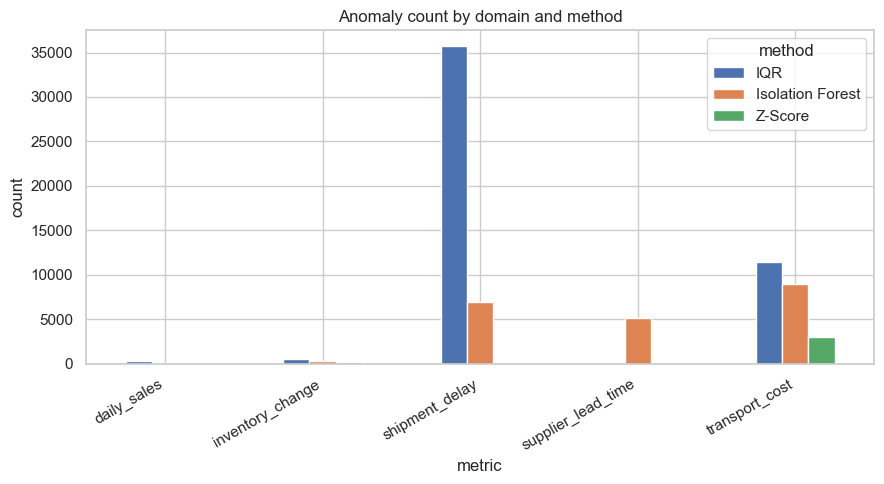

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
by_domain_method = anomalies.groupby(['metric', 'method']).size().unstack('method')
by_domain_method.plot(kind='bar', ax=ax)
ax.set_title('Anomaly count by domain and method')
ax.set_ylabel('count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Two patterns worth naming explicitly, not skating past:**

- `supplier_lead_time` shows **zero** IQR/Z-score anomalies for every supplier, only Isolation Forest. Real DataCo lead times only span 0-6 days per supplier (Q1=2, Q3=5) — the IQR fence covers the *entire possible range*, so threshold-based methods correctly find nothing to flag. Isolation Forest still flags ~5% regardless, because its `contamination` parameter forces a fixed proportion rather than requiring genuine dispersion — a real methodological difference between threshold-based and density-based detection, not a bug in either.
- IQR flags an unusually large share (~20%) of `shipment_delay` records. That domain's core distribution is tight (Q1=0, Q3=1), so the standard 1.5xIQR fence is only ±1.5 wide — on coarse, discrete-valued data like whole-day delays, that's narrow enough that legitimate tail values (-2, 3, 4 days) make up a sizable share. Verified by hand against the raw value counts; a domain-specific IQR multiplier would tighten this, not implemented here to keep one shared default per method across all 5 domains.

## 3. Example — daily sales

The network-wide daily revenue series with each method's flagged days marked, so the *shape* of what each method catches is visible, not just a count.

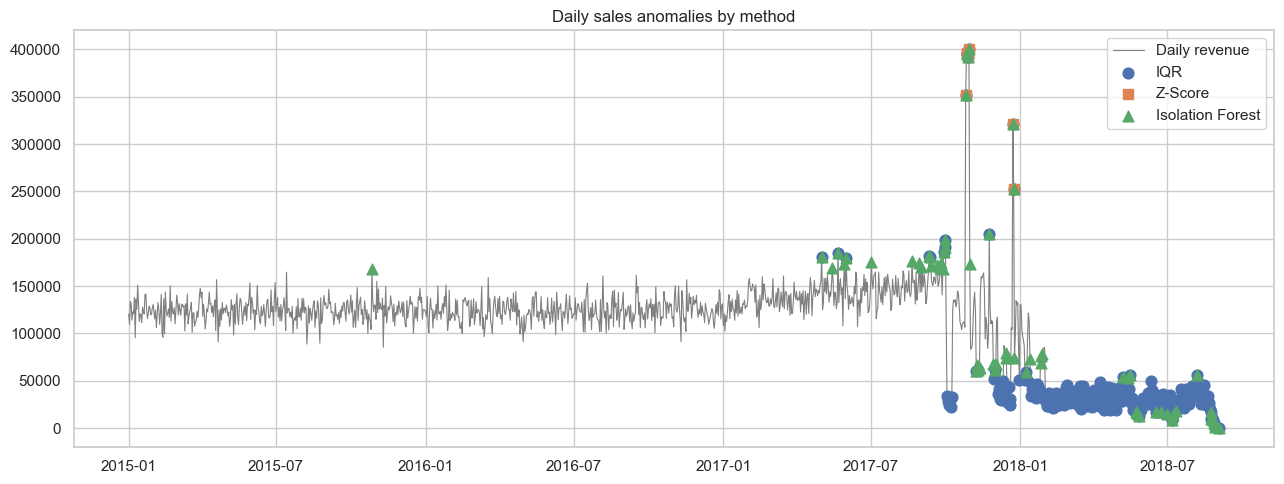

In [5]:
daily_sales = load_daily_sales()
sales_anomalies = detect_domain('daily_sales')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_sales['date'], daily_sales['value'], color='gray', linewidth=0.8, label='Daily revenue')
markers = {'IQR': 'o', 'Z-Score': 's', 'Isolation Forest': '^'}
colors = {'IQR': 'C0', 'Z-Score': 'C1', 'Isolation Forest': 'C2'}
for method in METHODS:
    subset = sales_anomalies[sales_anomalies['method'] == method]
    ax.scatter(
        subset['date'], subset['actual_value'],
        marker=markers[method], color=colors[method], label=method, s=60, zorder=3,
    )
ax.set_title('Daily sales anomalies by method')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Highest-severity anomalies across every domain

The rows a procurement/ops team would actually look at first.

In [6]:
high_severity = (
    anomalies[anomalies['severity'] == 'High']
    .sort_values('anomaly_score', ascending=False)
    .head(20)
)
high_severity

,anomaly_id,date,entity,metric,method,expected_value,actual_value,anomaly_score,severity
340,inventory_change|IQR|Abu Dhabi Distribution Ce...,2015-01-18,Abu Dhabi Distribution Center,inventory_change,IQR,-52.00,"1,749.00",22.99,High
346,inventory_change|IQR|Abu Dhabi Distribution Ce...,2015-05-03,Abu Dhabi Distribution Center,inventory_change,IQR,-52.00,"1,705.00",22.37,High
1249,inventory_change|IQR|Sharjah Distribution Cent...,2016-10-30,Sharjah Distribution Center,inventory_change,IQR,-35.00,"1,064.00",22.28,High
580,inventory_change|IQR|Ajman Distribution Center...,2016-11-02,Ajman Distribution Center,inventory_change,IQR,-79.50,"2,199.00",21.70,High
341,inventory_change|IQR|Abu Dhabi Distribution Ce...,2015-02-13,Abu Dhabi Distribution Center,inventory_change,IQR,-52.00,"1,656.00",21.69,High
1232,inventory_change|IQR|Sharjah Distribution Cent...,2016-03-04,Sharjah Distribution Center,inventory_change,IQR,-35.00,"1,036.00",21.66,High
347,inventory_change|IQR|Abu Dhabi Distribution Ce...,2015-05-30,Abu Dhabi Distribution Center,inventory_change,IQR,-52.00,"1,647.00",21.57,High
558,inventory_change|IQR|Ajman Distribution Center...,2016-01-29,Ajman Distribution Center,inventory_change,IQR,-79.50,"2,180.00",21.50,High
799,inventory_change|IQR|Dubai Distribution Center...,2017-01-15,Dubai Distribution Center,inventory_change,IQR,-84.00,"2,202.00",18.99,High
826,inventory_change|IQR|Dubai Distribution Center...,2017-09-09,Dubai Distribution Center,inventory_change,IQR,-84.00,"2,148.00",18.49,High


## 5. Save results

This run flags anomalies across the *entire* historical dataset in one pass — a demonstration of what each method catches, not a production alerting design. A real deployment would run incrementally (flag new data as it arrives, not re-flag history every run) and likely tune each domain's thresholds individually rather than sharing one default per method across all 5, per the observations above.

The saved report keeps only `severity == 'High'` — the rows worth a person's attention, consistent with every other report in `reports/` being a small curated summary rather than a raw data dump. The full `anomalies` DataFrame (all severities, all methods) is reproducible on demand via `detect_all()`; persisting all 72k+ flagged points to a git-tracked CSV would just be duplicating the warehouse data underneath it at low signal density.

In [7]:
from pathlib import Path

out_dir = Path('../reports/anomaly_detection')
out_dir.mkdir(parents=True, exist_ok=True)
high_severity_report = anomalies[anomalies['severity'] == 'High'].sort_values(
    'anomaly_score', ascending=False
)
high_severity_report.to_csv(out_dir / 'anomalies.csv', index=False)
print(
    f'Saved {len(high_severity_report)} high-severity anomalies '
    f'(of {len(anomalies)} flagged in total) to {out_dir.resolve()}'
)

Saved 5292 high-severity anomalies (of 72698 flagged in total) to E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\reports\anomaly_detection
